# Математическая статистика для анализа больших данных
## Задание 3
### Оценка максимального правдоподобия. Метод Ньютона.

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [1]:
# Bot check

# HW_ID: sbd_hw3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import scipy.stats as sps
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

np.random.seed(0)

## Задача 1. (5 баллов)

Найдите оценку параметра $\theta$ методом максимального правдоподобия по выборке размера $n$ из распределения:

a). $U(a,b), \theta=(a, b)$;

b). $U(\theta, 1+\theta)$;

Выполнены ли условия регулярности L1-L9? Если нет, то какое нарушается?


---
$a)$ $L_X(\theta) = \prod_{i=1}^n P(X_i|\theta) =  \frac{1}{(b-a)^n}$

$l_X(\theta) = ln(\frac{1}{(b-a)^n}) = nln(b-a) $

$\frac{∂l_X(a)}{∂l_X(θ)} = -\frac{n}{b-a}$

Чтобы максимизировать величину $-\frac{n}{b-a}$ необходимо увеличить знаменатель, максимум будет достигаться при $a=X_{(1)}$ и $b=X_{(n)}$

---
$b)$
$ P(x|\theta) = \frac{1}{1 + θ - θ} = 1$, если $x \in (θ, 1 + θ)$

$L_X(\theta) =  \frac{1}{(1)^n} = 1$, при том, что все $X_i \in (θ, 1 + θ)$.

Значит, чтобы функция правдоподобия должна обязательно включать, например, первый и последний элемент, то есть $\theta = X_{(1)}$ или $\theta = X_{(n)} - 1$.

---

$a)$
L1 выполняется: Семейство $\mathcal{P}$ является доминируемым. Плотность $p_\theta(x) = \frac{1}{b - a}$ на интервале $(a, b)$.  

L2 нарушается: Носитель зависит от $\theta$ (интервал $(a, b)$).  

L3 выполняется: $X = (X_1, \ldots, X_n)$ — выборка из неизвестного распределения $P \in \mathcal{P}$.

L4 выполняется: $\Theta$ — открытый интервал в $\mathbb{R}$.  

L5 нарушается: Плотность $p_\theta(x)$ дифференцируема по $\theta$ для любого $x \in A$.

L6 нарушается: Плотность $p_\theta(x)$ трижды непрерывно дифференцируема по $\theta$ для любого $x \in A$.

L7 нарушается: Логарифм плотности $p_\theta(x)$ трижды дифференцируем по $\theta$.

L8 нарушается: Информация Фишера $I(\theta)$ конечна и положительна.  

L9 нарушается: (Условие на третью производную).

---

$ b)$ L1 выполняется: Семейство $\mathcal{P}$ является доминируемым. Плотность $p_\theta(x) = 1$ на интервале $(\theta, 1+\theta)$.  

L2 нарушается: Носитель зависит от $\theta$ (интервал $(\theta, 1+\theta)$).  

L3 выполняется: $X = (X_1, \ldots, X_n)$ — выборка из неизвестного распределения $P \in \mathcal{P}$.

L4 выполняется: $\Theta$ — открытый интервал в $\mathbb{R}$.

L5 нарушается: Плотность $p_\theta(x)$ дифференцируема по $\theta$ для любого $x \in A$.

L6 нарушается: Плотность $p_\theta(x)$ трижды непрерывно дифференцируема по $\theta$ для любого $x \in A$.

L7 нарушается: Логарифм плотности $p_\theta(x)$ трижды дифференцируем по $\theta$.

L8 нарушается: Информация Фишера $I(\theta)$ конечна и положительна.

L9 нарушается: (Условие на третью производную).

## Задача 2. (5 баллов)

Пусть $X_1,\ldots,X_n$ &mdash; выборка из распределения $\mathcal{N}(a, \sigma^2)$, где $\theta=(a, \sigma)$ неизвестно. Для 0.95-квантили этого распределения найдите оценку максимального правдоподобия.

*Подсказка: пусть $z_\alpha$ &mdash; $\alpha$-квантиль стандартного нормального распределения, тогда $u_\alpha = a + z_\alpha \sigma$ &mdash; $\alpha$-квантиль распределения $\mathcal{N}(a, \sigma^2)$.* **Докажите этот факт.**

---
Пусть $z_\alpha$ — такое число, что $P(X \leq z_\alpha) = \alpha$, где $X \sim N(0,1)$.

Теперь рассмотрим случайную величину $Y = a + \sigma X$, где $X \sim N(0,1)$, тогда $Y \sim N(a, \sigma^2)$.
Найдём $\alpha$-квантиль для $Y$. Для этого используем следующее преобразование:
$$
\alpha = P(X \leq z_\alpha) = P(a + \sigma X \leq a + \sigma z_\alpha)
$$

Так как $a + \sigma X \sim N(a,\sigma^2)$, то $u_\alpha = a + z_\alpha \sigma$
 $\alpha$-квантиль распределения $\mathcal{N}(a, \sigma^2)$

---

Найдём $a$ и $\sigma$ с помощью ОМП.

Функция плотности нормального распределения:

$p(x;a,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - a)^2}{2\sigma^2}\right).$

$L(a,\sigma;X) = \prod_{i=1}^{n} p(X_i;a,\sigma).$

$\ell(a,\sigma) = \ln L(a,\sigma;X) = -n\ln\sigma - \frac{n}{2}\ln(2\pi) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (X_i - a)^2.$

Оценка для $a$:

$\frac{\partial \ell}{\partial a} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (X_i - a).$

$\frac{\partial \ell}{\partial a} = 0 \Rightarrow \sum_{i=1}^{n} (X_i - a) = 0.$

$a = \bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i.$

Оценка для $\sigma^2$:

$\frac{\partial \ell}{\partial \sigma} = -\frac{n}{\sigma} + \frac{1}{\sigma^3} \sum_{i=1}^{n} (X_i - a)^2.$

$-\frac{n}{\sigma} + \frac{1}{\sigma^3} \sum_{i=1}^{n} (X_i - a)^2 = 0.$

$-n\sigma^2 + \sum_{i=1}^{n} (X_i - a)^2 = 0.$

$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - a)^2.$

---

$\hat{a} = \bar{X}, \quad \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2.$

---

Рассмотрим полученное равенство:

$u_{0.95} = a + z_{0.95}\sigma$

Заметим, что если найти ОМП квантили для стандартного распределения, то можно найти и для любого.

Найдём 0.95 квантиль стандартного нормального распределения
$$F(x) = \frac{ 1 + erf(\frac{x}{\sqrt{2}})}{2} = 0.95.$$

$$x = \sqrt{2} \cdot \text{erf}^{-1}(0.9).$$

Итого:

$\hat{ u}_{0.95} = \bar{X} +  \sqrt{2} \cdot \text{erf}^{-1}(0.9) \sqrt{\frac{1}{n} \sum_{i=1}^{n} (X_i - a)^2}.$

---

## Задача 3. (1 балл)

Сгенерируйте выборку большого размера из стандартного нормального распределения и посчитайте её функцию правдоподобия в модели $\mathcal{N}(\theta, 1)$. Выполните код ниже:

In [3]:
theta = 5
sample = sps.norm.rvs(loc=theta, size=10**5)
likelihood = sps.norm.pdf(sample, loc=theta).prod()
print(likelihood)

0.0


Почему результат отличается от ожидаемого? Как обойти эту неприятность для подсчета оценки максимального правдоподобия? Реализуйте это.

*Подсказка:* нужно использовать некоторый метод класса, реализующий это распределение

**Ответ на вопрос и описание метода решения проблемы:**

Результат произведения равен 0, потому что при перемножении близких к нулю множителей происходит переполнение и результат обнуляется. Чтобы обойти эту неприятность, нужно прологарифмировать выражение, тогда вместо умножения будет использоваться сумма.

In [4]:
log_likelihood = sps.norm.logpdf(sample).sum()
print(log_likelihood)

-1392416.6505195354


In [5]:
theta_hat = sample.mean()
print("Выборочное среднее для θ", theta_hat)

def neg_log_likelihood(theta):
    return 0.5 * np.sum((sample - theta)**2)

result = minimize_scalar(neg_log_likelihood)
theta_mle = result.x
print("ОМП для θ:", theta_mle)

print("Разница между оценками:", abs(theta_hat - theta_mle))

Выборочное среднее для θ 5.001576700508126
ОМП для θ: 5.001576700508127
Разница между оценками: 8.881784197001252e-16


**Вывод:** Для того, чтобы избежать обнуления функции правдоподобия с большими выборками необходимо учитывать численные ограничения компьютеров. Логарифмирование функций правдоподобия — эффективный способ избежать переполнения и получить корректные результаты.

## Задача 4.  (15 баллов)
Компания выпустила $n$ серверов новой модели с увеличенным сроком службы. До начала продаж компания должна провести эксперимент по оценке среднего срока службы серверов. Известно, что сервера могут сломаться в любой момент независимо от того, сколько времени уже проработали. Таким образом, распределение времени работы сервера до поломки обладает свойством отсутствия памяти. Как вы знаете, таким свойством среди непрерывных распределений обладает только экспоненциальное распределение.

Компания начала проводить эксперимент, но сервера получились настолько хорошими, что многие еще не сломались, а бизнес уже требует запускать их продажи. Тем самым усложняется задача для аналитиков, которым приходит "обрезанная" выборка.

Рассмотрим задачу более формально. Пусть $X = (X_1, \ldots, X_n)$ &mdash; выборка из экспоненциального распределения с параметром $\theta$ с плотностью $p_\theta(x) = \theta e^{-\theta x}I\{x \geq 0\}$. \
При этом наблюдается выборка $Y = (Y_1, \ldots, Y_n)$, где, $Y_i$ определены следующим образом:
$$
\begin{equation}
  Y_i=\begin{cases}
    X_i, & \text{если $X_i \leq c$}.\\
    c, & \text{если $X_i > c$}.
  \end{cases}
\end{equation}
$$
Иначе говоря, $Y_i = \min(X_i, c)$, где $c$ &mdash; некоторая константа.
Выборка является смесью непрерывного и дискретного распределения, поэтому функция правдоподобия не определена. Вам предлагается реализовать и сравнить три подхода к оценке неизвестного параметра:
1. Рассмотреть подвыборку, состоящую из $Y_i < c$, и найти для нее ОМП. Учтите, что необходимо использовать условное распределение $Y_i$ при условии $Y_i < c$.
2. Найти оценку, используя метод моментов.
3. Найти ОМП по дискретизованной выборке, выполнив следующие действия.

    а) Разбить полуинтервал $[0, c)$ на $k$ бинов (множеств) вида $[a_i, a_{i+1})$, где $0=a_0<a_1<...<a_k=c$. В качестве границ бинов возьмите целые числа.
    
    б) Определить $Z_i$ как номер бина, в который попадает $Y_i$, считая при этом множество $\{c\}$ как $(k+1)$-й бин. Вам может помочь функция [`np.digitize`](https://numpy.org/doc/stable/reference/generated/numpy.digitize.html).
    
    в) Найти вероятности $p_j(\theta) = \mathsf{P}_\theta(Z_1 = j)$, которые определяют распределение $Z_i$, являющееся дискретным.
    
    г) Найти ОМП по выборке $Z_1, ..., Z_n$, используя ее распределение.

Рассмотрите $c = 10$, а в качестве истинного значения параметра возьмите $\theta = 0.15$. Обратите внимание на параметризацию в [`scipy.stats.expon`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html).
Получить точный ответ в виде формулы у вас скорее всего не получится, воспользуйтесь численными методами.

Насколько точным получается оценка в зависимости от подхода и размера выборки?

**Решение:**

---
$1.$  Пусть в подвыборке $Y_i$ содержится m элементов, выпишем для него условную плотность вероятности, посчитаем функцию правдоподобия, и найдём при каком $\theta$ функция достигает минимума:

$$p_{Y|Y<c}(x)= p_{X|X<c}(x) = \frac{\theta e^{-\theta x}}{1 - \theta e^{-\theta c}}$$

$$ \ell(Y) = \sum_{i=1}^m ln(p_{Y|Y<c}(Y_i)) = \sum_{i=1}^m ln(\frac{\theta e^{-\theta Y_i}}{1 - \theta e^{-\theta c}}) = \sum_{i=1}^m  ln(\theta e^{-\theta Y_i}) - \sum_{i=1}^m ln(1 - \theta e^{-\theta c}) = mln(\theta) - m \theta \bar{Y}  - mln(1 - \theta e^{-\theta c})$$

$\frac{∂ℓ}{∂θ} = 0: $


$$\frac{m}{θ} - m\bar{Y} - m\frac{c θ e ^{-θc} - e^{-θc}}{1-θe^{-θc}} = 0$$

$$\frac{1}{θ} - \bar{Y} - \frac{c θ e ^{-θc} - e^{-θc}}{1-θe^{-θc}} = 0$$

Чтобы найти оптимальное значение θ, будем использовать численный метод оптимизации minimize_scalar.

In [6]:
def estimate_theta_mle_subsample(Y, c):
    """Оценивает параметр θ методом
    максимального правдоподобия для подвыборки.

    :param Y: выборка наблюдений
    :param c: пороговое значение
    :return: оценка θ
    """
    Y_less_c = Y[Y < c]
    m = len(Y_less_c)
    S = np.sum(Y_less_c)

    def neg_log_likelihood(theta):
        if theta <= 0:
            return np.inf
        denom = 1 - np.exp(-theta * c)
        if denom <= 0:
            return np.inf
        term1 = m * np.log(theta)
        term2 = -theta * S
        term3 = -m * np.log(denom)
        return -(term1 + term2 + term3)

    result = minimize_scalar(neg_log_likelihood, bounds=(1e-6, 1), \
                             method='bounded')
    return result.x


---
$2.$ Используем метод моментов:
$$\bar{Y} = E_θ(Y_1) = \int_{0}^{c} x p_θ(x)dx + c P_θ(X > c)
 = \int_0^c y \cdot \theta e^{-\theta y} \, dy + c \cdot e^{-\theta c}. $$


$$ \int_0^c y \cdot e^{-\theta y} \, dy = \left[ -\frac{y}{\theta} e^{-\theta y} - \frac{1}{\theta^2} e^{-\theta y} \right]_0^c = -\frac{c}{\theta} e^{-\theta c} - \frac{1}{\theta^2} e^{-\theta c} + \frac{1}{\theta^2}. = -\frac{c}{\theta} e^{-\theta c} - \frac{1}{\theta^2} e^{-\theta c} + \frac{1}{\theta^2}. $$


$$ E_{\theta}(Y_1) = \left( -c e^{-\theta c} - \frac{1}{\theta} e^{-\theta c} + \frac{1}{\theta} \right) + c e^{-\theta c} = \frac{1}{\theta} \left( 1 - e^{-\theta c} \right). $$


$$ \overline{Y} = \frac{1}{\theta} \left( 1 - e^{-\theta c} \right). $$

Чтобы найти значение θ, будем использовать численный метод оптимизации minimize_scalar.


In [7]:
def estimate_theta_moments(Y, c):
    """Оценивает параметр θ методом моментов.

    :param Y: выборка наблюдений
    :param c: пороговое значение
    :return: оценка θ
    """
    Y_bar = np.mean(Y)

    def moment_equation(theta):
        if theta <= 0:
            return np.inf
        expected_Y = (1 - np.exp(-theta * c)) / theta
        return (expected_Y - Y_bar)**2

    result = minimize_scalar(moment_equation, bounds=(1e-6, 1), \
                             method='bounded')
    return result.x


---
3. Реализуем алгоритм:

In [8]:
def estimate_theta_mle_discrete(Y, c, k):
    """Оценивает параметр θ методом
    максимального правдоподобия для дискретных данных.

    :param Y: выборка наблюдений
    :param c: пороговое значение
    :param k: количество интервалов
    :return: оценка θ
    """
    bins = np.linspace(0, c, k+1)
    Z = np.digitize(Y, bins, right=False) - 1
    n_j = np.bincount(Z, minlength=k+1)

    def p_j(theta):
        if theta <= 0:
            return np.full(k+1, np.nan)
        p = np.zeros(k+1)
        for j in range(k):
            a_j = bins[j]
            a_j1 = bins[j+1]
            p[j] = np.exp(-theta * a_j) - np.exp(-theta * a_j1)
        p[k] = np.exp(-theta * c)
        return p

    def log_likelihood(theta):
        pj = p_j(theta)
        if np.any(pj <= 0) or np.any(np.isnan(pj)):
            return -np.inf
        return np.sum(n_j * np.log(pj))

    def neg_log_likelihood(theta):
        return -log_likelihood(theta)

    result = minimize_scalar(neg_log_likelihood, bounds=(1e-6, 1), \
                             method='bounded')
    return result.x


---
Насколько точным получается оценка в зависимости от подхода и размера выборки?

In [9]:
def draw_multiple_confidence_intervals(
    sample_sizes,
    estimations,
    intervals,
    true_theta,
    labels,
    colors,
    ylim=(None, None)
):
    """Рисует доверительные интервалы и оценки
    для нескольких методов на одном графике.

    :param sample_sizes: размеры выборки
    :param estimations: список массивов оценок (по методам)
    :param intervals: список кортежей (левая граница, правая граница)
     доверительных интервалов (по методам)
    :param true_theta: истинное значение θ
    :param labels: список меток для каждого метода
    :param colors: список цветов для каждого метода
    :param ylim: ограничение вертикальной оси
    """
    plt.figure(figsize=(14, 8))

    for i, (est, (left, right), label, color) in \
    enumerate(zip(estimations, intervals, labels, colors)):
        plt.plot(sample_sizes, est, color=color, \
                 label=f'Оценка θ ({label})', marker='o', linestyle='-')
        plt.fill_between(sample_sizes, left, right, color=color, \
                         alpha=0.2, label=f'ДИ ({label})')

    plt.axhline(y=true_theta, color='r', \
                linestyle='dashed', label='Истинное θ')
    plt.xlabel('Размер выборки n')
    plt.ylabel('Оценка θ')
    plt.title(
        'Зависимость оценок θ и доверительных '
        'интервалов от размера выборки'
    )
    plt.legend()
    plt.ylim(ylim)
    plt.grid(True)
    plt.show()

In [10]:
def bootstrap_confidence_interval(
    data, estimator_func, B=200, alpha=0.05
):
    """Вычисляет доверительный интервал с помощью бутстрап-метода.

    :param data: исходные данные
    :param estimator_func: функция оценивания параметра
    :param B: количество бутстрап-репликаций
    :param alpha: уровень значимости для доверительных интервалов
    :return: нижняя и верхняя границы доверительного интервала
    """
    estimates = []
    n = len(data)
    for _ in range(B):
        sample_indices = np.random.choice(n, n, replace=True)
        sample = data[sample_indices]
        estimate = estimator_func(sample)
        estimates.append(estimate)
    estimates = np.array(estimates)
    lower = np.percentile(estimates, 100 * alpha / 2)
    upper = np.percentile(estimates, 100 * (1 - alpha / 2))
    return lower, upper

def compute_estimates_and_intervals(
    Y_full, sample_sizes, c, k, B, alpha
):
    """Вычисляет оценки и доверительные
    интервалы для нескольких методов.

    :param Y_full: полная выборка наблюдений
    :param sample_sizes: размеры выборки
    :param c: пороговое значение
    :param k: количество интервалов для дискретного метода
    :param B: количество бутстрап-репликаций
    :param alpha: уровень значимости для доверительных интервалов
    :return: словарь с оценками и доверительными интервалами
    """
    theta_mle_list = []
    theta_mom_list = []
    theta_mle_discrete_list = []

    ci_mle_left = []
    ci_mle_right = []
    ci_mom_left = []
    ci_mom_right = []
    ci_mle_discrete_left = []
    ci_mle_discrete_right = []

    for n in sample_sizes:
        Y = Y_full[:n]
        theta_mle = estimate_theta_mle_subsample(Y, c)
        theta_mom = estimate_theta_moments(Y, c)
        theta_mle_discrete = estimate_theta_mle_discrete(Y, c, k)
        theta_mle_list.append(theta_mle)
        theta_mom_list.append(theta_mom)
        theta_mle_discrete_list.append(theta_mle_discrete)

        if not np.isnan(theta_mle):
            estimator_mle = (
                lambda sample: \
                estimate_theta_mle_subsample(sample, c)
            )
            left, right = bootstrap_confidence_interval(
                Y, estimator_mle, B=B, alpha=alpha
            )
            ci_mle_left.append(left)
            ci_mle_right.append(right)
        else:
            ci_mle_left.append(np.nan)
            ci_mle_right.append(np.nan)

        estimator_mom = \
        lambda sample: estimate_theta_moments(
            sample, c
        )
        left, right = bootstrap_confidence_interval(
            Y, estimator_mom, B=B, alpha=alpha
        )
        ci_mom_left.append(left)
        ci_mom_right.append(right)

        estimator_mle_discrete = (
            lambda sample: \
            estimate_theta_mle_discrete(sample, c, k)
        )
        left, right = bootstrap_confidence_interval(
            Y, estimator_mle_discrete, B=B, alpha=alpha
        )
        ci_mle_discrete_left.append(left)
        ci_mle_discrete_right.append(right)

    ci_mle_left = np.array(ci_mle_left)
    ci_mle_right = np.array(ci_mle_right)
    ci_mom_left = np.array(ci_mom_left)
    ci_mom_right = np.array(ci_mom_right)
    ci_mle_discrete_left = np.array(ci_mle_discrete_left)
    ci_mle_discrete_right = np.array(ci_mle_discrete_right)

    return {
        "theta_mle_list": theta_mle_list,
        "theta_mom_list": theta_mom_list,
        "theta_mle_discrete_list": theta_mle_discrete_list,
        "ci_mle_left": ci_mle_left,
        "ci_mle_right": ci_mle_right,
        "ci_mom_left": ci_mom_left,
        "ci_mom_right": ci_mom_right,
        "ci_mle_discrete_left": ci_mle_discrete_left,
        "ci_mle_discrete_right": ci_mle_discrete_right,
    }


In [11]:
def plot_confidence_intervals(
    sample_sizes,
    ci_mle_left,
    ci_mle_right,
    ci_mom_left,
    ci_mom_right,
    ci_mle_discrete_left,
    ci_mle_discrete_right,
    theta_true,
):
    """Строит график доверительных интервалов для различных методов.

    :param sample_sizes: размеры выборки
    :param ci_mle_left: левая граница доверительного интервала (метод 1)
    :param ci_mle_right: правая граница доверительного интервала (метод 1)
    :param ci_mom_left: левая граница доверительного интервала (метод 2)
    :param ci_mom_right: правая граница доверительного интервала (метод 2)
    :param ci_mle_discrete_left:
    левая граница доверительного интервала (метод 3)
    :param ci_mle_discrete_right:
    правая граница доверительного интервала (метод 3)
    :param theta_true: истинное значение θ
    """
    plt.figure(figsize=(14, 8))

    plt.fill_between(
        sample_sizes,
        ci_mle_left,
        ci_mle_right,
        color="#FF3300",
        alpha=0.2,
        label="ДИ (Метод 1)",
    )
    plt.fill_between(
        sample_sizes,
        ci_mom_left,
        ci_mom_right,
        color="#0066FF",
        alpha=0.2,
        label="ДИ (Метод 2)",
    )
    plt.fill_between(
        sample_sizes,
        ci_mle_discrete_left,
        ci_mle_discrete_right,
        color="#9933FF",
        alpha=0.2,
        label="ДИ (Метод 3)",
    )

    plt.axhline(
        y=theta_true, color="r", linestyle="dashed", label="Истинное θ"
    )
    plt.xlabel("Размер выборки n")
    plt.ylabel("Оценка θ")
    plt.title(
        "Доверительные интервалы для оценки θ "
        "в зависимости от размера выборки"
    )
    plt.legend()
    plt.ylim(0, 0.3)
    plt.grid(True)
    plt.show()


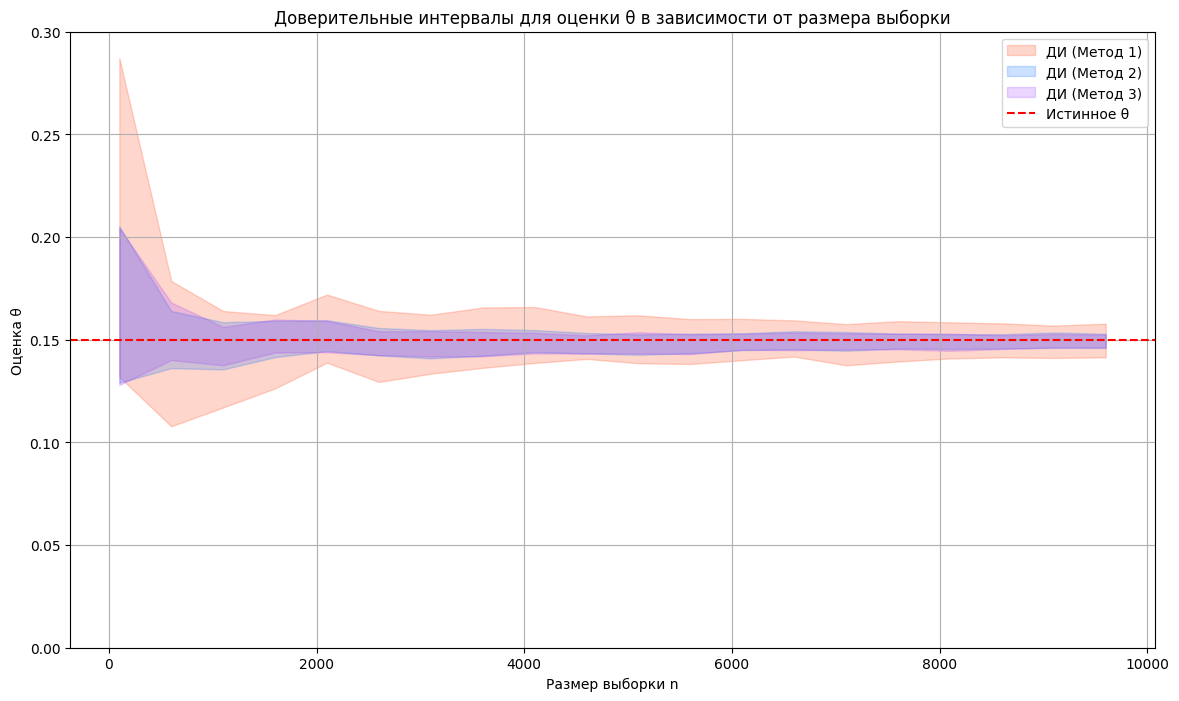

In [12]:
theta_true = 0.15
c = 10
k = int(c)
sample_sizes = np.arange(100, 10001, 500)
B = 200
alpha = 0.05

max_n = sample_sizes[-1]
X_full = sps.expon.rvs(scale=1/theta_true, size=max_n)
Y_full = np.minimum(X_full, c)

results = compute_estimates_and_intervals(
    Y_full, sample_sizes, c, k, B, alpha
)

plot_confidence_intervals(
    sample_sizes,
    results['ci_mle_left'], results['ci_mle_right'],
    results['ci_mom_left'], results['ci_mom_right'],
    results['ci_mle_discrete_left'], results['ci_mle_discrete_right'],
    theta_true
)

---
**Вывод:** На графике видно, что доверительные интервалы для оценки параметра
$\theta$ сужаются с увеличением размера выборки, что соответствует ожидаемой сходимости оценок к истинному значению при больших $n$. Метод 1, использующий только подвыборку $Y_i < c$, демонстрирует более широкие доверительные интервалы, особенно при малых размерах выборки, из-за потери информации от цензурированных данных, что увеличивает дисперсию оценок. Методы 2 и 3, которые используют всю выборку, включая цензурированные наблюдения, показывают более узкие и почти совпадающие интервалы, что указывает на их меньшую дисперсию. Это объясняется тем, что эти методы используют больше информации из данных, что способствует более точным оценкам, которые быстрее приближаются к истинному значению параметра с ростом объема выборки. Сужение интервалов и сходимость оценок к $\theta$ подтверждают, что использование полной выборки улучшает точность оценивания.

---